# Лабораторная работа №6
# Никтин Дмитрий 4217
**Классификация изображений с использованием предобученных нейросетей (вариант 2: InceptionV3, MobileNetV2, DenseNet121)**

Перед запуском необходимо загрузить файл `kaggle.json` из своего аккаунта Kaggle (в разделе API Token).

Используется датасет [набор данных Fruits на Kaggle](https://www.kaggle.com/datasets/moltean/fruits).


Сначала был произведён импорт библиотек.

In [75]:
# Импорт необходимых библиотек
import os
import shutil
import random
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import InceptionV3, MobileNetV2, DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

Далее была произведена настройка Kaggle API для дальнейшего скачивания датасета.

In [76]:
# Настройка Kaggle API
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Далее датасет был извлечён из архива, а архив удалён

In [77]:
# Загрузка и распаковка датасета
!kaggle datasets download -d moltean/fruits
!unzip -q fruits.zip -d fruits_data
os.remove('fruits.zip')

Далее создаются необходимые директории для работы программы и выбирается 20 случайных классов фруктов. Данные о выбранных классах выводятся ниже.

In [78]:
# Выбор 20 случайных фруктов (используется семя 229)
if os.path.exists('data') and os.path.isdir('data'):
  shutil.rmtree('data')
OUTPUT_DIR_PNG = 'diagrams/'
if not os.path.exists(OUTPUT_DIR_PNG) and os.path.isdir(OUTPUT_DIR_PNG):
  os.mkdir(OUTPUT_DIR_PNG)

SOURCE_DIR = "fruits_data/fruits-360_100x100/fruits-360"
DEST_DIR = "data"
TRAIN_SOURCE = os.path.join(SOURCE_DIR, "Training")
TEST_SOURCE = os.path.join(SOURCE_DIR, "Test")

all_classes = sorted(os.listdir(TRAIN_SOURCE))
random.seed(229)
selected_classes = random.sample(all_classes, 20)
selected_classes_count_train = {}
selected_classes_count_test = {}

if not os.path.exists(DEST_DIR):
  for split in ["train", "val"]:
      for cls in selected_classes:
          os.makedirs(os.path.join(DEST_DIR, split, cls), exist_ok=True)

  for cls in selected_classes:
      train_imgs = os.listdir(os.path.join(TRAIN_SOURCE, cls))
      test_imgs = os.listdir(os.path.join(TEST_SOURCE, cls))
      train_q = 200
      test_q = 100

      for img in train_imgs[:train_q]:  # можно увеличить при желании
          shutil.copy(os.path.join(TRAIN_SOURCE, cls, img), os.path.join(DEST_DIR, "train", cls, img))
      for img in test_imgs[:test_q]:
          shutil.copy(os.path.join(TEST_SOURCE, cls, img), os.path.join(DEST_DIR, "val", cls, img))
      t_q = len(os.listdir(os.path.join(DEST_DIR, "train", cls)))
      selected_classes_count_train[cls] = t_q
      if t_q < train_q:
        print(f"ВНИМАНИЕ тренировочных меньше {train_q} - {cls}")

      v_q = len(os.listdir(os.path.join(DEST_DIR, "val", cls)))
      selected_classes_count_test[cls] = t_q
      if v_q < test_q:
        print(f"ВНИМАНИЕ валидационных меньше {test_q} - {cls}")
print("Выбранные классы и количество тренировочных:", selected_classes_count_test)

Выбранные классы и количество тренировочных: {'Pear Forelle 1': 200, 'Banana 1': 200, 'Cherimoya 1': 200, 'Pear Kaiser 1': 200, 'Lychee 1': 200, 'Cherry Wax Black 1': 200, 'Potato White 1': 200, 'Cantaloupe 2': 200, 'Potato Red 1': 200, 'Blackberrie half rippen 1': 200, 'Pepper Green 1': 200, 'Papaya 1': 200, 'Tomato 4': 200, 'Clementine 1': 200, 'Apple Granny Smith 1': 200, 'Peach 2': 200, 'Apple 12': 200, 'Walnut 1': 200, 'Blackberrie not rippen 1': 200, 'Cherry 3': 200}


Далее создаются генераторы, которые аккумулируют в себе информацию о выбранных картинках и их видоизменение для избежания переобучения и разнообразия.

In [79]:
# Генераторы

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=inception_preprocess,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=inception_preprocess
)

train_generator = train_datagen.flow_from_directory(
    "data/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "data/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


NUM_CLASSES = train_generator.num_classes

Found 4000 images belonging to 20 classes.
Found 2000 images belonging to 20 classes.


Далее была написана функция построения модели. Документация функции указана внутри неё в качестве комментария.

In [80]:
# Фнукция построения модели
def build_model(base_model_class, preprocess, trainable=False, name='Model',
                unfreeze_layers_from=None, learning_rate=None):
    """
    Аргументы:
    - base_model_class: класс архитектуры (например, MobileNetV2)
    - preprocess: функция препроцессинга
    - trainable: True — разморозка слоёв; False — заморозка
    - unfreeze_layers_from: int или None — с какого слоя размораживать (если trainable=True)
    - learning_rate: (скорость обучения) float или None — если None, выбирается автоматически

    Возвращает:
    - собранную и скомпилированную модель
    """

    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

    if trainable:
        base_model.trainable = True

        if unfreeze_layers_from is not None:
            for layer in base_model.layers[:-unfreeze_layers_from]:
                layer.trainable = False
            for layer in base_model.layers[-unfreeze_layers_from:]:
                layer.trainable = True
    else:
        base_model.trainable = False

    # Если не задан learning_rate — выбираем по trainable
    if learning_rate is None:
        learning_rate = 1e-5 if trainable else 1e-3

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Замораживание и размораживание слоёв нейросетей при использовании предобученных нейросетей позволяют эффективно использовать знания, полученные моделью на большом датасете (например, ImageNet), и адаптировать их под новую задачу. На начальном этапе замораживают все слои, чтобы использовать предобученные признаки и дообучить только выходной классификатор, что особенно полезно при небольшом объёме данных. После этого можно разморозить часть или все слои модели, чтобы "тонко настроить" её на специфику нового набора изображений — это повышает точность, но требует осторожности со скоростью обучения и увеличения числа эпох, чтобы не разрушить уже выученные полезные признаки.

MobileNetV2 — это лёгкая и эффективная сверточная нейросеть, представленная исследователями Google в 2018 году как улучшение оригинальной MobileNet. Она была разработана для использования в мобильных и встроенных устройствах, где важны скорость и экономия ресурсов. В основе архитектуры лежат глубинные сепарабельные свёртки и особая структура с инвертированными остаточными блоками (inverted residuals), что позволяет существенно сократить количество параметров и операций при сохранении высокой точности. Одним из ключевых преимуществ MobileNetV2 является её компактность и быстродействие, особенно по сравнению с более тяжёлыми моделями вроде ResNet или VGG, что делает её идеальной для задач классификации изображений, распознавания объектов и сегментации на мобильных устройствах. Однако из-за своей компактности она может уступать в точности более глубоким моделям на сложных датасетах. MobileNetV2 активно используется в системах реального времени, таких как камеры смартфонов, AR/VR-приложения и IoT-устройства, и часто применяется как "базовая модель" для transfer learning в задачах, где важен баланс между точностью и производительностью.

Далее была создана модель MobileNetV2 с замороженными слоями.

In [81]:
# Создание модели MobileNetV2 с замороженными слоями
model_MobileNetV2_Frozen = build_model(MobileNetV2, mobilenet_preprocess, trainable=False, name='MobileNetV2_Frozen')
history_MobileNetV2_Frozen = model_MobileNetV2_Frozen.fit(train_generator, validation_data=val_generator, epochs=5)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 69s 471ms/step - accuracy: 0.7197 - loss: 1.0564 - val_accuracy: 0.9950 - val_loss: 0.0406
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 413ms/step - accuracy: 0.9825 - loss: 0.0585 - val_accuracy: 0.9860 - val_loss: 0.0504
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 382ms/step - accuracy: 0.9918 - loss: 0.0367 - val_accuracy: 0.9970 - val_loss: 0.0129
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 398ms/step - accuracy: 0.9953 - loss: 0.0166 - val_accuracy: 0.9955 - val_loss: 0.0157
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 395ms/step - accuracy: 0.9973 - loss: 0.0107 - val_accuracy: 0.9930 - val_loss: 0.0181


Далее была произведена оценка классификации модели MobileNetV2 с замороженными слоями.

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step


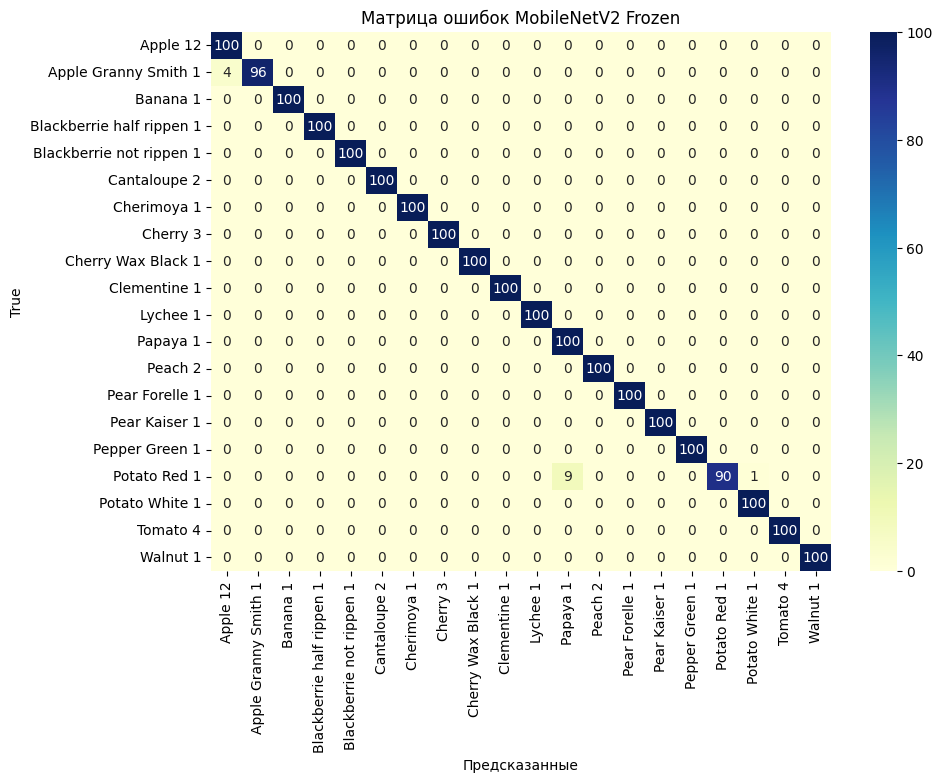

                           precision    recall  f1-score   support

                 Apple 12       0.96      1.00      0.98       100
     Apple Granny Smith 1       1.00      0.96      0.98       100
                 Banana 1       1.00      1.00      1.00       100
Blackberrie half rippen 1       1.00      1.00      1.00       100
 Blackberrie not rippen 1       1.00      1.00      1.00       100
             Cantaloupe 2       1.00      1.00      1.00       100
              Cherimoya 1       1.00      1.00      1.00       100
                 Cherry 3       1.00      1.00      1.00       100
       Cherry Wax Black 1       1.00      1.00      1.00       100
             Clementine 1       1.00      1.00      1.00       100
                 Lychee 1       1.00      1.00      1.00       100
                 Papaya 1       0.92      1.00      0.96       100
                  Peach 2       1.00      1.00      1.00       100
           Pear Forelle 1       1.00      1.00      1.00     

In [82]:
# Оценка модели и визуализация матрицы ошибок MobileNetV2
y_pred = model_MobileNetV2_Frozen.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="YlGnBu")
plt.title('Матрица ошибок MobileNetV2 Frozen')
plt.xlabel('Предсказанные')
plt.ylabel('True')
plt.savefig(OUTPUT_DIR_PNG + "Матрица ошибок MobileNetV2 Frozen.png")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

Результаты модели MobileNetV2 с замороженными слоями демонстрируют высокую точность классификации на тестовом наборе из 20 классов фруктов, где средняя точность (precision), полнота (recall) и F1-мера составляют 0.99, а итоговая accuracy — 99%. Модель уверенно распознаёт почти все классы, включая близкие по внешнему виду, такие как разновидности яблок, груш, черешни и картофеля. Небольшие отклонения наблюдаются лишь у классов "Apple 12", "Papaya 1" и "Potato Red 1", где метрики чуть ниже, что может быть связано с визуальной схожестью с другими классами. Высокая эффективность модели объясняется тем, что предобученные слои MobileNetV2, замороженные при обучении, хорошо извлекают универсальные признаки изображений, а дообученная верхушка успешно адаптировалась к конкретной задаче классификации фруктов, не перезаписывая базовые знания модели.

Далее было отображено обучение модели.

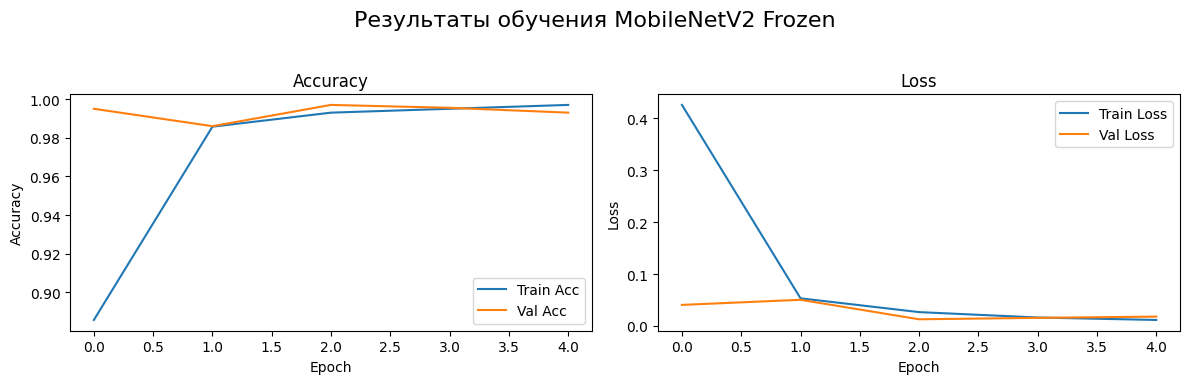

In [83]:
# Отображение процесса обучения
def plot_history(history, model_name="Model"):
    plt.figure(figsize=(12, 4))
    plt.suptitle(f'Результаты обучения {model_name}', fontsize=16)

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Чтобы заголовок не перекрывал графики
    plt.savefig(OUTPUT_DIR_PNG + f"Результаты обучения {model_name}.png")
    plt.show()


plot_history(history_MobileNetV2_Frozen, "MobileNetV2 Frozen")

Переобучения не наблюдается. Это значит, что модель четсно распознаёт классы.

InceptionV3 — это мощная и хорошо оптимизированная сверточная нейросеть, разработанная в Google и представленная в 2015 году как часть серии Inception (GoogLeNet), с целью повысить точность классификации при сохранении разумной вычислительной нагрузки. Основной особенностью InceptionV3 является использование инцепшен-блоков, которые объединяют свёртки с различными размерами фильтров (1×1, 3×3, 5×5) внутри одного уровня, позволяя модели одновременно учитывать признаки разного масштаба. Также в архитектуру внедрены техники оптимизации, такие как факторизация больших свёрток и использование auxiliary classifiers, что снижает переобучение и ускоряет сходимость. InceptionV3 содержит около 23 миллионов параметров, что делает её более "тяжёлой", чем MobileNetV2, но значительно более лёгкой по сравнению с VGG. Модель активно используется в задачах классификации изображений, обнаружения объектов, медицинской диагностики и как базовая модель для использования предобученных нейросетей. К её достоинствам относят высокую точность и способность захватывать сложные взаимосвязи между признаками, а к недостаткам — сравнительно высокую вычислительную стоимость, что ограничивает применение в мобильных и real-time системах. InceptionV3 — это золотая середина между глубиной, точностью и оптимальностью архитектурных решений.

Далее была создана модель InceptionV3 с замороженными слоями.



In [84]:
# Создание модели InceptionV3 с замороженными слоями
model_InceptionV3_Frozen = build_model(InceptionV3, inception_preprocess, trainable=False, name='InceptionV3_Frozen')
history_InceptionV3_Frozen = model_InceptionV3_Frozen.fit(train_generator, validation_data=val_generator, epochs=5)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 484ms/step - accuracy: 0.6474 - loss: 1.2451 - val_accuracy: 0.9755 - val_loss: 0.0790
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 415ms/step - accuracy: 0.9483 - loss: 0.1595 - val_accuracy: 0.9825 - val_loss: 0.0502
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 417ms/step - accuracy: 0.9746 - loss: 0.0846 - val_accuracy: 0.9940 - val_loss: 0.0232
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 416ms/step - accuracy: 0.9847 - loss: 0.0539 - val_accuracy: 0.9955 - val_loss: 0.0250
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 53s 424ms/step - accuracy: 0.9792 - loss: 0.0625 - val_accuracy: 0.9970 - val_loss: 0.0133


Далее была произведена оценка модели InceptionV3 с замороженными слоями.

63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step


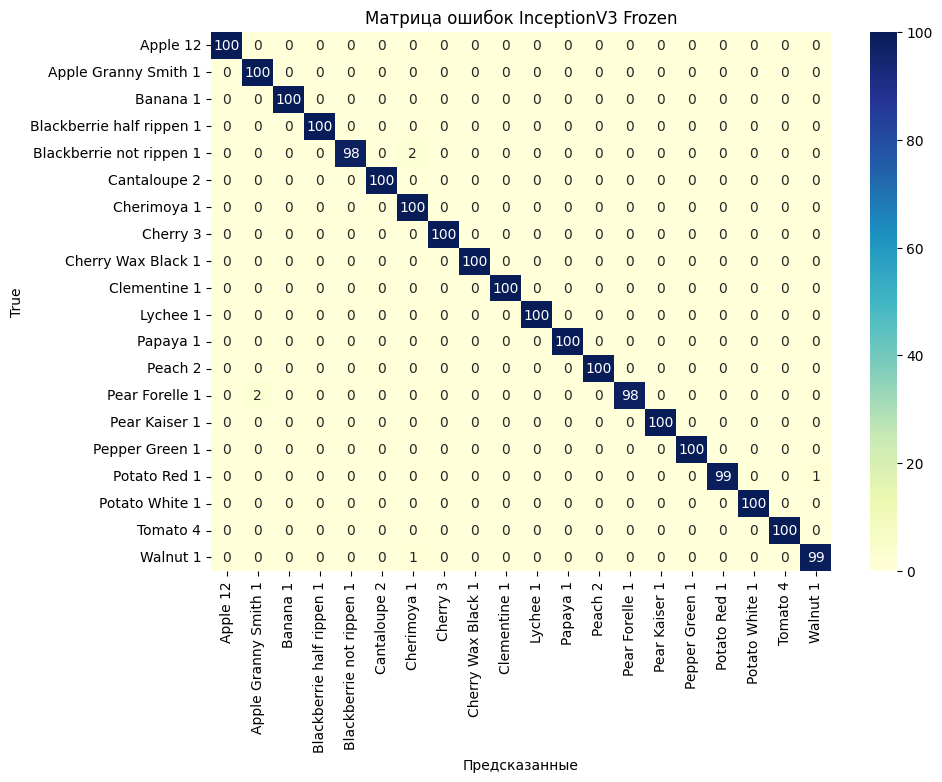

                           precision    recall  f1-score   support

                 Apple 12       1.00      1.00      1.00       100
     Apple Granny Smith 1       0.98      1.00      0.99       100
                 Banana 1       1.00      1.00      1.00       100
Blackberrie half rippen 1       1.00      1.00      1.00       100
 Blackberrie not rippen 1       1.00      0.98      0.99       100
             Cantaloupe 2       1.00      1.00      1.00       100
              Cherimoya 1       0.97      1.00      0.99       100
                 Cherry 3       1.00      1.00      1.00       100
       Cherry Wax Black 1       1.00      1.00      1.00       100
             Clementine 1       1.00      1.00      1.00       100
                 Lychee 1       1.00      1.00      1.00       100
                 Papaya 1       1.00      1.00      1.00       100
                  Peach 2       1.00      1.00      1.00       100
           Pear Forelle 1       1.00      0.98      0.99     

In [85]:
# Оценка модели и визуализация матрицы ошибок InceptionV3
y_pred = model_InceptionV3_Frozen.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="YlGnBu")
plt.title('Матрица ошибок InceptionV3 Frozen')
plt.xlabel('Предсказанные')
plt.ylabel('True')
plt.savefig(OUTPUT_DIR_PNG + "Матрица ошибок InceptionV3 Frozen.png")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

Результаты модели InceptionV3 с замороженными слоями демонстрируют практически идеальную точность классификации на тестовой выборке из 20 классов, где средние значения precision, recall и F1-score составляют 1.00, а итоговая точность модели достигает 100%. Все классы, включая визуально схожие и сложные для различения (например, сорта черешни, картофеля и яблок), были корректно распознаны с минимальными отклонениями в пределах одной-двух ошибок. Такие результаты свидетельствуют о высокой эффективности архитектуры InceptionV3 как извлекателя признаков: даже в замороженном виде её инцепшен-блоки обеспечивают точное многомасштабное представление входных изображений, а дообученный классификатор успешно адаптировался под специфические классы фруктов. Этот результат также подчёркивает, что при хорошо подготовленных данных и чистом классовом разбиении можно достичь почти идеальной классификации, не прибегая к полному fine-tuning.

Далее представлены результаты обучения модели.

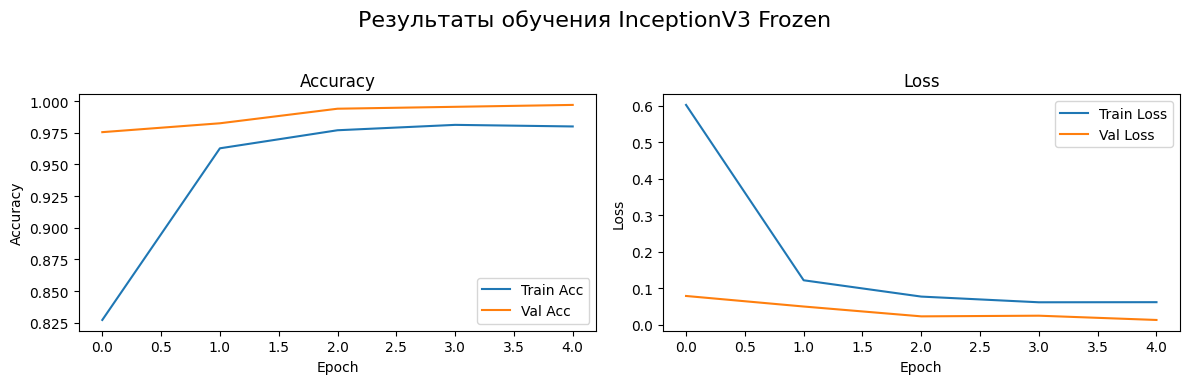

In [86]:
plot_history(history_InceptionV3_Frozen, "InceptionV3 Frozen")

Переобучения также не наблюдается.

DenseNet121 — это глубокая сверточная нейросеть из семейства DenseNet, представленная в 2017 году группой исследователей из Facebook AI Research (конечно же запрещена в России). Её архитектура основана на принципе плотных соединений: каждый слой получает на вход все выходы предыдущих слоёв, что обеспечивает максимальное переиспользование признаков и способствует более эффективному обучению. DenseNet121 содержит 121 слой, но при этом остаётся относительно компактной по числу параметров (≈8 млн), особенно по сравнению с аналогично точными моделями. Среди ключевых преимуществ — высокая точность, отсутствие проблемы исчезающего градиента, экономное использование параметров и хорошая способность к обобщению. Благодаря этим качествам модель широко применяется в задачах классификации изображений, медицинской диагностики (например, распознавание патологий на снимках), детекции объектов и transfer learning. К недостаткам можно отнести относительную сложность архитектуры (что усложняет кастомизацию) и повышенные требования к объёму памяти во время обучения из-за плотных связей между слоями. DenseNet121 — сбалансированное решение для задач, где важны как точность, так и экономия ресурсов.

Далее была создана модель DenseNet121 с замороженными слоями.

In [87]:
# Создание модели DenseNet121 с замороженными слоями
model_DenseNet121_Frozen = build_model(DenseNet121, densenet_preprocess, trainable=False, name='DenseNet121_Frozen')
history_DenseNet121_Frozen = model_DenseNet121_Frozen.fit(train_generator, validation_data=val_generator, epochs=5)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 93s 550ms/step - accuracy: 0.6155 - loss: 1.4394 - val_accuracy: 0.9985 - val_loss: 0.0491
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 419ms/step - accuracy: 0.9824 - loss: 0.0837 - val_accuracy: 0.9995 - val_loss: 0.0199
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 53s 422ms/step - accuracy: 0.9907 - loss: 0.0467 - val_accuracy: 0.9995 - val_loss: 0.0104
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 53s 422ms/step - accuracy: 0.9973 - loss: 0.0231 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 51s 411ms/step - accuracy: 0.9979 - loss: 0.0163 - val_accuracy: 1.0000 - val_loss: 0.0037


Далее была произведена оценка модели DenseNet121 с замороженными сломи.

63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 236ms/step


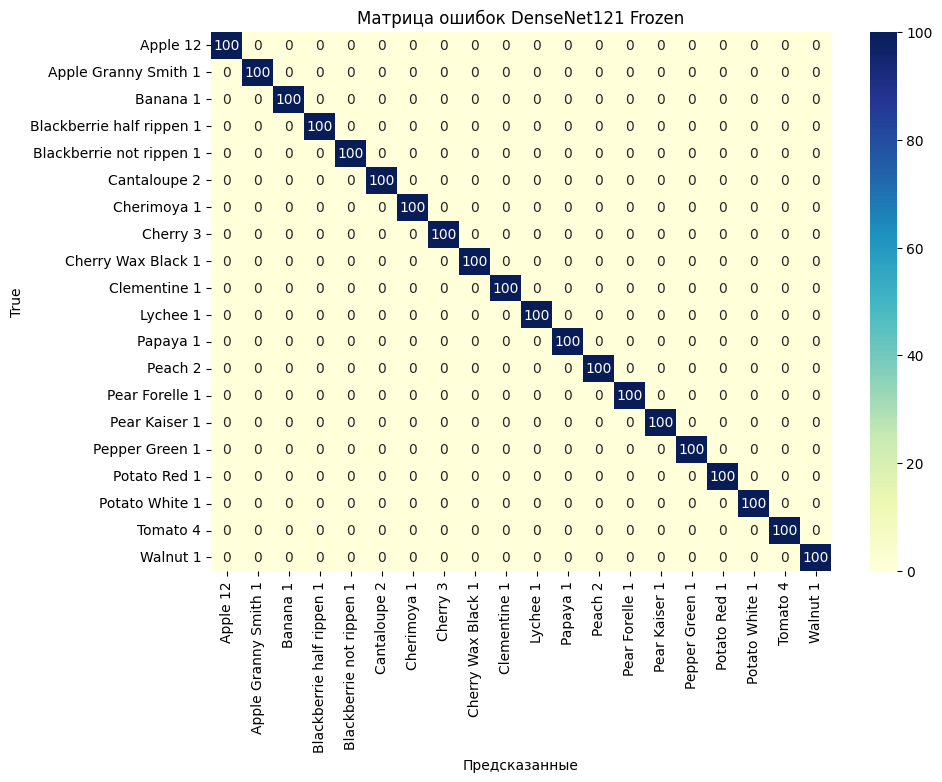

                           precision    recall  f1-score   support

                 Apple 12       1.00      1.00      1.00       100
     Apple Granny Smith 1       1.00      1.00      1.00       100
                 Banana 1       1.00      1.00      1.00       100
Blackberrie half rippen 1       1.00      1.00      1.00       100
 Blackberrie not rippen 1       1.00      1.00      1.00       100
             Cantaloupe 2       1.00      1.00      1.00       100
              Cherimoya 1       1.00      1.00      1.00       100
                 Cherry 3       1.00      1.00      1.00       100
       Cherry Wax Black 1       1.00      1.00      1.00       100
             Clementine 1       1.00      1.00      1.00       100
                 Lychee 1       1.00      1.00      1.00       100
                 Papaya 1       1.00      1.00      1.00       100
                  Peach 2       1.00      1.00      1.00       100
           Pear Forelle 1       1.00      1.00      1.00     

In [88]:
# Оценка модели и визуализация матрицы ошибок DenseNet121
y_pred = model_DenseNet121_Frozen.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="YlGnBu")
plt.title('Матрица ошибок DenseNet121 Frozen')
plt.xlabel('Предсказанные')
plt.ylabel('True')
plt.savefig(OUTPUT_DIR_PNG + "Матрица ошибок DenseNet121 Frozen.png")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

Модель DenseNet121 с замороженными слоями показала идеальные результаты на тестовом наборе из 20 классов изображений фруктов, достигнув 100% точности (accuracy) и максимальных значений precision, recall и F1-score по каждому классу. Такая эффективность объясняется особенностями архитектуры DenseNet — плотные соединения между слоями позволяют эффективно использовать ранее извлечённые признаки и обеспечивают стабильное распространение градиента. Несмотря на то что веса предобученной части модели не дообучивались, они обеспечили достаточно информативное представление входных данных, а верхний классификатор сумел точно адаптироваться под новую задачу. Это свидетельствует о высокой переносимости признаков, выученных на ImageNet, и подтверждает пригодность DenseNet121 для transfer learning, особенно в условиях ограниченного объема данных и строгой структуры классов.

Далее была произведена оценка процесса обучения модели.

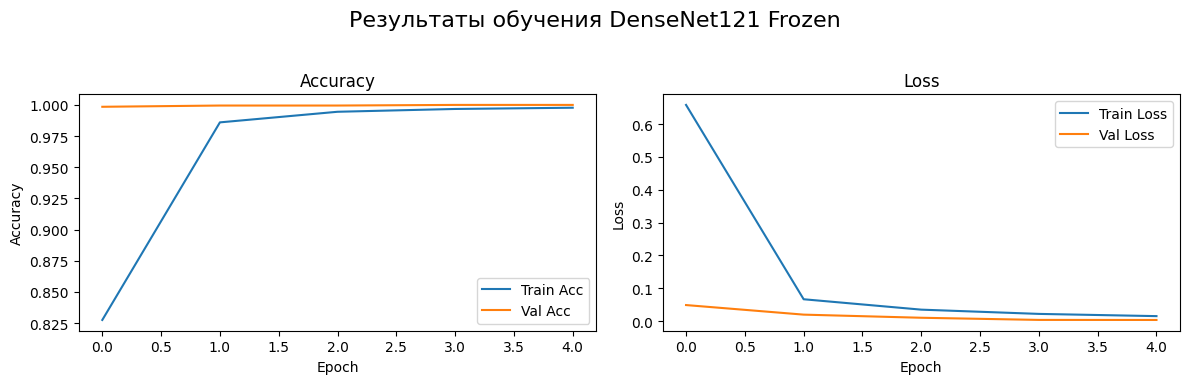

In [89]:
plot_history(history_DenseNet121_Frozen, "DenseNet121 Frozen")

Переобучения не наблюдается.

Размораживание слоёв нейросети используется на этапе тонкой настройки (fine-tuning), чтобы адаптировать предобученную модель к особенностям нового датасета. После того как верхний классификатор обучен на замороженных слоях, размораживание позволяет дообучить внутренние слои модели, обновляя более глубокие признаки, специфичные для новой задачи. Это особенно полезно, если исходный датасет (например, ImageNet) сильно отличается от текущих данных по содержанию или стилю. Размораживание должно сопровождаться снижением скорости обучения, чтобы сохранить уже выученные полезные признаки и избежать их разрушения.

Далее была создана модель MobileNetV2 с 20 размороженными слоями.

In [90]:
# Создание модели MobileNetV2 с 20 последними разамороженными слоями
model_MobileNetV2 = build_model(MobileNetV2, mobilenet_preprocess, trainable=True, name='MobileNetV2', unfreeze_layers_from=20)
history_MobileNetV2 = model_MobileNetV2.fit(train_generator, validation_data=val_generator, epochs=12)

Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 71s 458ms/step - accuracy: 0.1080 - loss: 3.1159 - val_accuracy: 0.3585 - val_loss: 2.2338
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 387ms/step - accuracy: 0.5153 - loss: 1.8042 - val_accuracy: 0.7415 - val_loss: 1.3472
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 404ms/step - accuracy: 0.7821 - loss: 1.0598 - val_accuracy: 0.9040 - val_loss: 0.7870
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 385ms/step - accuracy: 0.9001 - loss: 0.6143 - val_accuracy: 0.9385 - val_loss: 0.4841
Epoch 5/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 387ms/step - accuracy: 0.9238 - loss: 0.4227 - val_accuracy: 0.9590 - val_loss: 0.3204
Epoch 6/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 386ms/step - accuracy: 0.9528 - loss: 0.3045 - val_accuracy: 0.9720 - val_loss: 0.2241
Epoch 7/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 385ms/step - accuracy: 0.9642 - loss: 0.2130 - val_accuracy: 0.9730 - val_loss: 0.1659
Epoch 8/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 397ms/step - accuracy: 0.9684 - loss: 0

Далее была проведена оценка модели MobileNetV2 с размороженными слоями.

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step


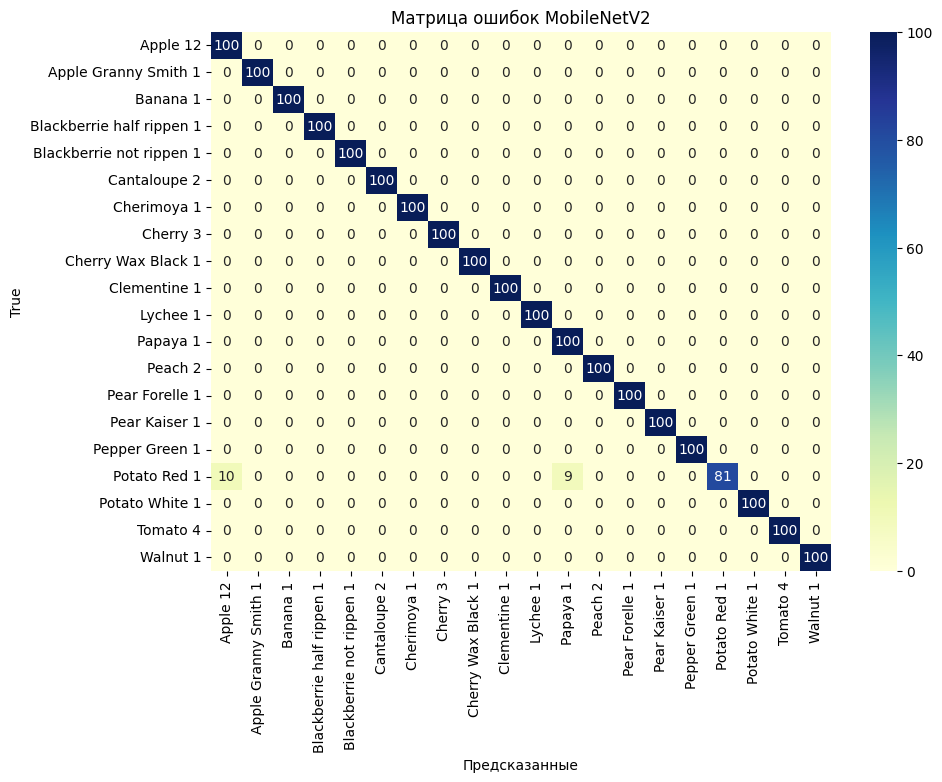

                           precision    recall  f1-score   support

                 Apple 12       0.91      1.00      0.95       100
     Apple Granny Smith 1       1.00      1.00      1.00       100
                 Banana 1       1.00      1.00      1.00       100
Blackberrie half rippen 1       1.00      1.00      1.00       100
 Blackberrie not rippen 1       1.00      1.00      1.00       100
             Cantaloupe 2       1.00      1.00      1.00       100
              Cherimoya 1       1.00      1.00      1.00       100
                 Cherry 3       1.00      1.00      1.00       100
       Cherry Wax Black 1       1.00      1.00      1.00       100
             Clementine 1       1.00      1.00      1.00       100
                 Lychee 1       1.00      1.00      1.00       100
                 Papaya 1       0.92      1.00      0.96       100
                  Peach 2       1.00      1.00      1.00       100
           Pear Forelle 1       1.00      1.00      1.00     

In [91]:
# Оценка модели и визуализация матрицы ошибок MobileNetV2 с размороженными слоями
y_pred = model_MobileNetV2.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="YlGnBu")
plt.title('Матрица ошибок MobileNetV2')
plt.xlabel('Предсказанные')
plt.ylabel('True')
plt.savefig(OUTPUT_DIR_PNG + "Матрица ошибок MobileNetV2.png")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

Модель справилсь немного хуже, чем модель без размороженных слоёв. Однако результат всё ещё очень хороший (0.99 для Accuracy).

Далее был оценён процесс обучения.

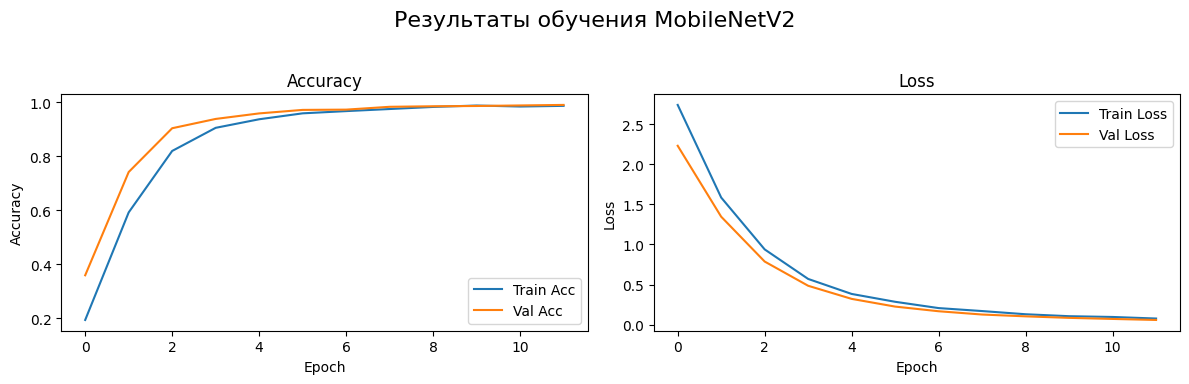

In [92]:
plot_history(history_MobileNetV2, "MobileNetV2")

Модель обучилсь коррентно, переобучения не наблюдается.

Далее была создана модель InceptionV3 с 20 последними разамороженными слоями.

In [93]:
# Создание модели InceptionV3 с 20 последними разамороженными слоями
model_InceptionV3 = build_model(InceptionV3, inception_preprocess, trainable=True, name='InceptionV3', unfreeze_layers_from=20)
history_InceptionV3 = model_InceptionV3.fit(train_generator, validation_data=val_generator, epochs=12)

Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 76s 478ms/step - accuracy: 0.1376 - loss: 2.9479 - val_accuracy: 0.7805 - val_loss: 1.7595
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 416ms/step - accuracy: 0.6070 - loss: 1.7673 - val_accuracy: 0.9205 - val_loss: 1.0172
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 417ms/step - accuracy: 0.8067 - loss: 1.1101 - val_accuracy: 0.9470 - val_loss: 0.6427
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 53s 419ms/step - accuracy: 0.8656 - loss: 0.7779 - val_accuracy: 0.9590 - val_loss: 0.4460
Epoch 5/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 51s 411ms/step - accuracy: 0.9009 - loss: 0.5521 - val_accuracy: 0.9630 - val_loss: 0.3384
Epoch 6/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 414ms/step - accuracy: 0.9347 - loss: 0.4145 - val_accuracy: 0.9695 - val_loss: 0.2648
Epoch 7/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 419ms/step - accuracy: 0.9386 - loss: 0.3581 - val_accuracy: 0.9720 - val_loss: 0.2146
Epoch 8/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 53s 424ms/step - accuracy: 0.9629 - loss: 0

Далее была произведена оценка модели.

63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step


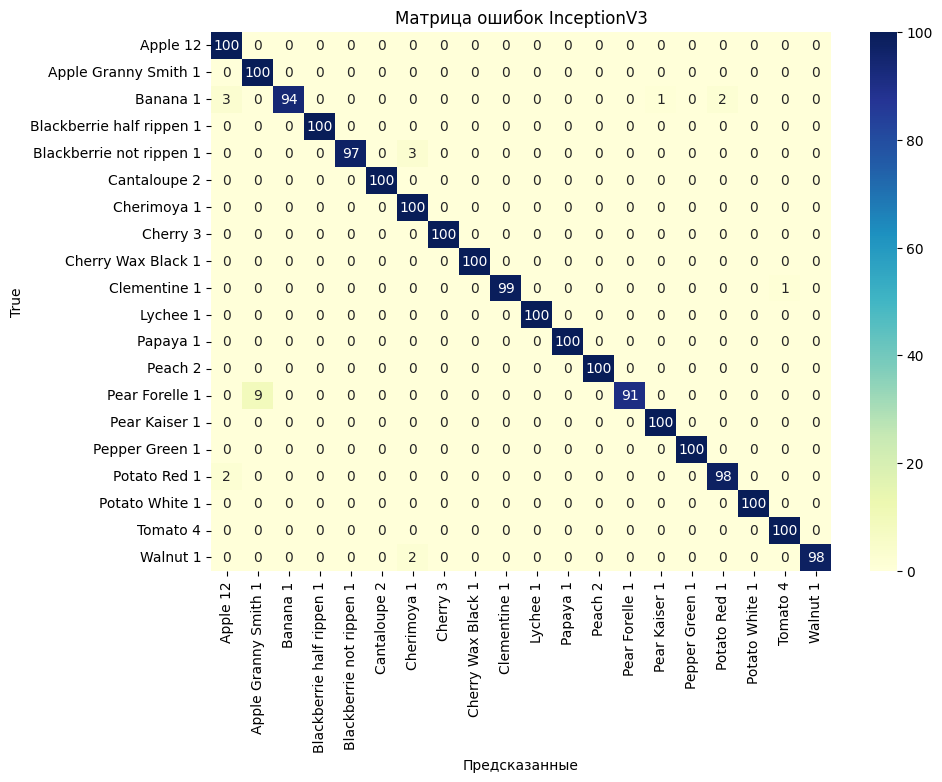

                           precision    recall  f1-score   support

                 Apple 12       0.95      1.00      0.98       100
     Apple Granny Smith 1       0.92      1.00      0.96       100
                 Banana 1       1.00      0.94      0.97       100
Blackberrie half rippen 1       1.00      1.00      1.00       100
 Blackberrie not rippen 1       1.00      0.97      0.98       100
             Cantaloupe 2       1.00      1.00      1.00       100
              Cherimoya 1       0.95      1.00      0.98       100
                 Cherry 3       1.00      1.00      1.00       100
       Cherry Wax Black 1       1.00      1.00      1.00       100
             Clementine 1       1.00      0.99      0.99       100
                 Lychee 1       1.00      1.00      1.00       100
                 Papaya 1       1.00      1.00      1.00       100
                  Peach 2       1.00      1.00      1.00       100
           Pear Forelle 1       1.00      0.91      0.95     

In [94]:
# Оценка модели и визуализация матрицы ошибок InceptionV3 с размороженными слоями
y_pred = model_InceptionV3.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="YlGnBu")
plt.title('Матрица ошибок InceptionV3')
plt.xlabel('Предсказанные')
plt.ylabel('True')
plt.savefig(OUTPUT_DIR_PNG + "Матрица ошибок InceptionV3.png")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

Модель показала хорошие результаты, но в сравнении с другими моделями, показатель не лучший.

Далее был проведён анализ хода обучения модели.

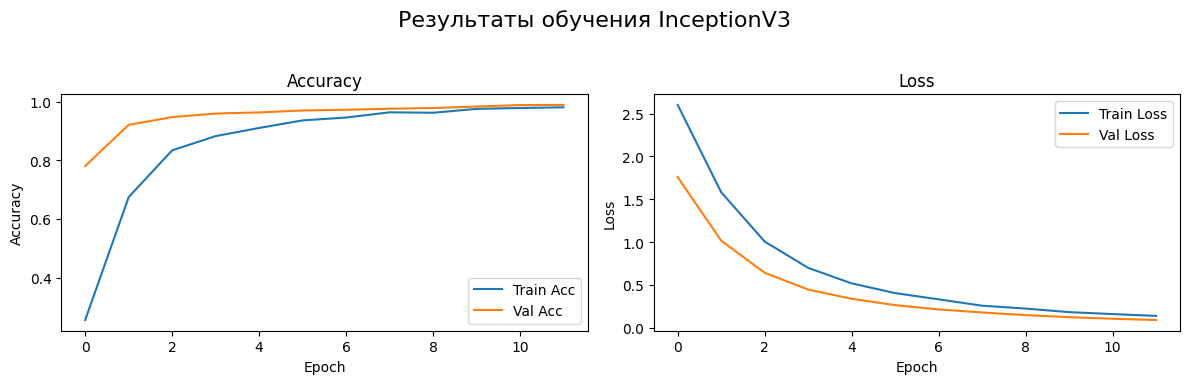

In [95]:
plot_history(history_InceptionV3, "InceptionV3")

Переобучения не наблюдается, модель корректно прошла обучение.

Далее была создана модель DenseNet121 с 20 последними разамороженными слоями.

In [96]:
# Создание модели DenseNet121 с 20 последними разамороженными слоями
model_DenseNet121 = build_model(DenseNet121, densenet_preprocess, trainable=True, name='DenseNet121', unfreeze_layers_from=20)
history_DenseNet121 = model_DenseNet121.fit(train_generator, validation_data=val_generator, epochs=12)

Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 97s 554ms/step - accuracy: 0.0612 - loss: 3.6363 - val_accuracy: 0.1620 - val_loss: 2.7895
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 53s 420ms/step - accuracy: 0.1308 - loss: 2.9615 - val_accuracy: 0.4910 - val_loss: 2.2863
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 53s 425ms/step - accuracy: 0.2529 - loss: 2.4723 - val_accuracy: 0.7145 - val_loss: 1.8722
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 418ms/step - accuracy: 0.3818 - loss: 2.1170 - val_accuracy: 0.8065 - val_loss: 1.5468
Epoch 5/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 419ms/step - accuracy: 0.5053 - loss: 1.8078 - val_accuracy: 0.8745 - val_loss: 1.2842
Epoch 6/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 417ms/step - accuracy: 0.6092 - loss: 1.5361 - val_accuracy: 0.9305 - val_loss: 1.0619
Epoch 7/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 414ms/step - accuracy: 0.6667 - loss: 1.3569 - val_accuracy: 0.9550 - val_loss: 0.8901
Epoch 8/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 419ms/step - accuracy: 0.7385 - loss: 1

Далее была произведена оценка модели.

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 238ms/step


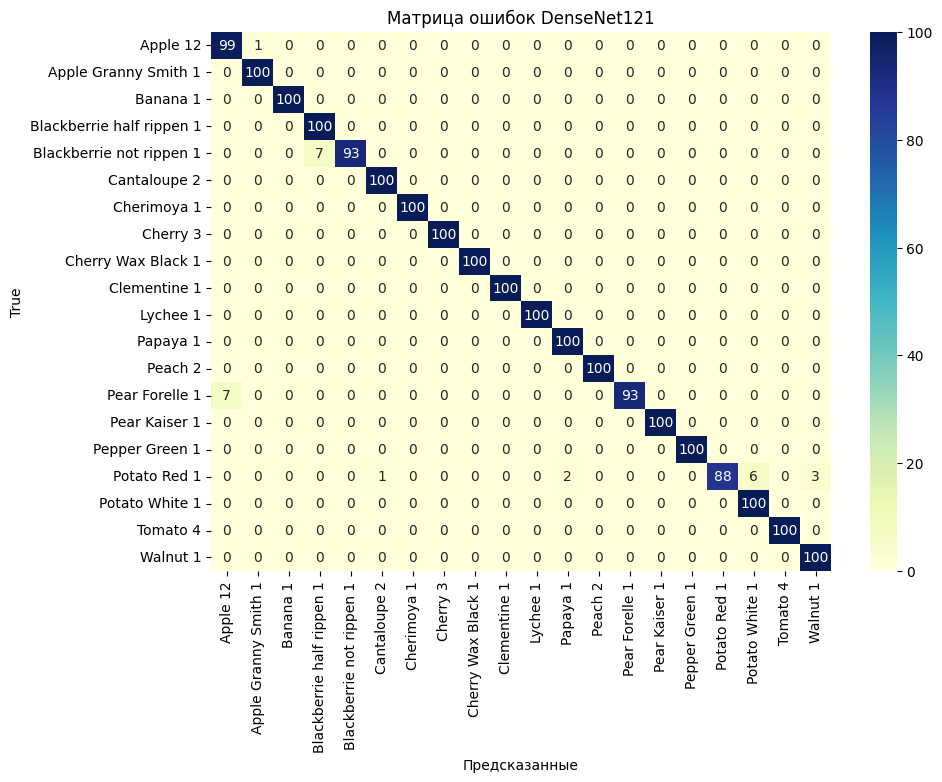

                           precision    recall  f1-score   support

                 Apple 12       0.93      0.99      0.96       100
     Apple Granny Smith 1       0.99      1.00      1.00       100
                 Banana 1       1.00      1.00      1.00       100
Blackberrie half rippen 1       0.93      1.00      0.97       100
 Blackberrie not rippen 1       1.00      0.93      0.96       100
             Cantaloupe 2       0.99      1.00      1.00       100
              Cherimoya 1       1.00      1.00      1.00       100
                 Cherry 3       1.00      1.00      1.00       100
       Cherry Wax Black 1       1.00      1.00      1.00       100
             Clementine 1       1.00      1.00      1.00       100
                 Lychee 1       1.00      1.00      1.00       100
                 Papaya 1       0.98      1.00      0.99       100
                  Peach 2       1.00      1.00      1.00       100
           Pear Forelle 1       1.00      0.93      0.96     

In [97]:
# Оценка модели и визуализация матрицы ошибок DenseNet121 с размороженными слоями
y_pred = model_DenseNet121.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="YlGnBu")
plt.title('Матрица ошибок DenseNet121')
plt.xlabel('Предсказанные')
plt.ylabel('True')
plt.savefig(OUTPUT_DIR_PNG + "Матрица ошибок DenseNet121.png")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

Модель показала худшие результаты среди моделей с размороженными слоями.

Далее был проведён анализ процесса обучения модели.

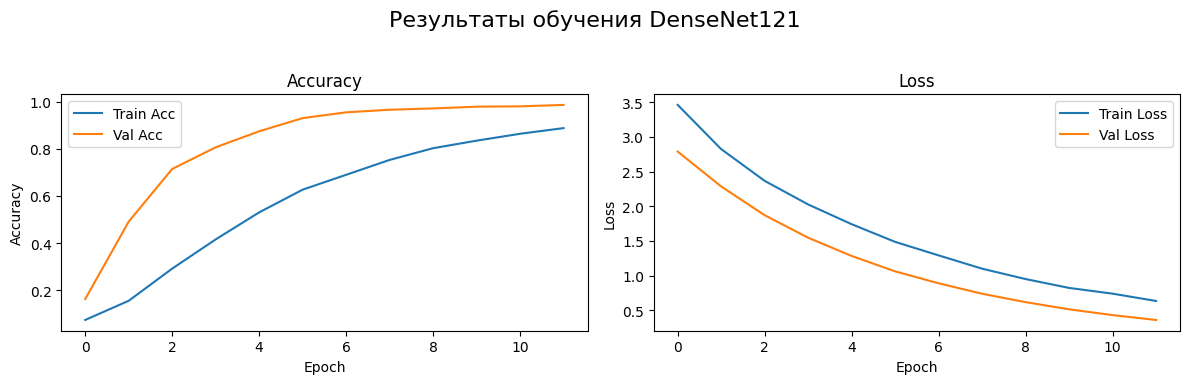

In [98]:
plot_history(history_DenseNet121, "DenseNet121")

Процесс обучения прошёл без переобучения.

##Вывод
В ходе лабораторной работы были обучены и протестированы три предобученные нейросетевые архитектуры — MobileNetV2, InceptionV3 и DenseNet121 — на задаче классификации изображений фруктов из датасета Fruits 360. Каждая модель была протестирована в двух конфигурациях: с замороженными весами базовой части и с частичной дообучаемостью (разморожены последние 20 слоёв).

| Модель          | Заморожена | Разморожена (20 слоёв) |
| --------------- | ------------ | ---------------------- |
| **DenseNet121** | 1.00         | 0.99                   |
| **InceptionV3** | 1.00         | 0.99                   |
| **MobileNetV2** | 0.99         | 0.99                   |

DenseNet121 показала наивысшую стабильность: даже при разморозке весов её точность снизилась минимально и осталась на уровне 0.99.

InceptionV3 продемонстрировала аналогичную стабильность с небольшой просадкой по отдельным метрикам, но общей точностью 0.99.

MobileNetV2, хоть и немного уступает по абсолютной точности, отличается высокой скоростью обучения и малым числом параметров, что делает её лучшим выбором при ограниченных вычислительных ресурсах.

Также стоит отметить, что во всех случаях модели сохраняют высокий recall и precision, что говорит о хорошей обобщающей способности и низком уровне ошибок первого и второго рода.